# Báo cáo: Phát hiện tấn công DDoS bằng Machine Learning

**Mục tiêu:**
- Phân tích và khám phá tập dữ liệu tấn công mạng CIC-DDoS2019.
- Xây dựng các mô hình học máy (Machine Learning) để phân loại lưu lượng mạng thành hai loại: **Bình thường (BENIGN)** và **Tấn công (DDoS)**.
- Đánh giá hiệu quả của các mô hình và lựa chọn mô hình tốt nhất.
- 

In [4]:
# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Các công cụ từ Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.feature_selection import SelectFromModel # ĐÃ XÓA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC

# Các mô hình Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression # THAY THẾ XGBOOST
from sklearn.cluster import KMeans # THAY THẾ ISOLATION FOREST
import joblib

# Các thư viện Deep Learning đã bị loại bỏ
# import tensorflow as tf
# ... (các dòng keras khác đã bị xóa) ...

# Tắt các cảnh báo không cần thiết để báo cáo sạch sẽ hơn
import warnings
warnings.filterwarnings('ignore')

## Tải và kiểm tra dữ liệu

In [5]:

def tai_du_lieu(duong_dan):
    """
    Tải dữ liệu từ file CSV và loại bỏ các khoảng trắng thừa trong tên cột.
    """
    print(f"Đang tải dữ liệu từ: {duong_dan}")
    df = pd.read_csv(duong_dan)
    df.columns = df.columns.str.strip()
    print("Tải dữ liệu thành công!")
    return df

In [6]:

duong_dan_file = './Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
du_lieu_tho = tai_du_lieu(duong_dan_file)

# Hiển thị 5 dòng đầu tiên để kiểm tra
print("\n5 dòng dữ liệu đầu tiên:")
display(du_lieu_tho.head())

Đang tải dữ liệu từ: ./Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


Tải dữ liệu thành công!

5 dòng dữ liệu đầu tiên:


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
def kham_pha_du_lieu(df):
    """
    Thực hiện EDA, bao gồm:
    1. In thông tin tổng quan.
    2. Vẽ biểu đồ cột và biểu đồ tròn thể hiện phân phối của nhãn.
    """
    print("--- BẮT ĐẦU PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) ---")
    print("\n1. Thông tin tổng quan về dữ liệu:")
    print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

    # 2. Kiểm tra phân phối của nhãn
    print("\n2. Phân phối của các loại lưu lượng mạng (nhãn):")
    label_counts = df['Label'].value_counts()
    print(label_counts)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Biểu đồ cột
    sns.countplot(ax=axes[0], x='Label', data=df)
    axes[0].set_title('Phân phối số lượng giữa lưu lượng Benign và DDoS', fontsize=14)
    axes[0].set_xlabel('Loại lưu lượng', fontsize=12)
    axes[0].set_ylabel('Số lượng', fontsize=12)
    
    # Biểu đồ tròn
    axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
    axes[1].set_title('Tỷ lệ % giữa lưu lượng Benign và DDoS', fontsize=14)
    axes[1].set_ylabel('') # Bỏ nhãn y của biểu đồ tròn
    
    plt.tight_layout()
    
    # --- THÊM DÒNG NÀY ĐỂ LƯU BIỂU ĐỒ ---
    plt.savefig('eda_phan_phoi_nhan.png', dpi=300, bbox_inches='tight')
    
    plt.show()
    print("--- KẾT THÚC EDA ---")

In [8]:
# import os
# os.listdir("/kaggle/working")

--- BẮT ĐẦU PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) ---

1. Thông tin tổng quan về dữ liệu:
Số dòng: 225745, Số cột: 85

2. Phân phối của các loại lưu lượng mạng (nhãn):
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


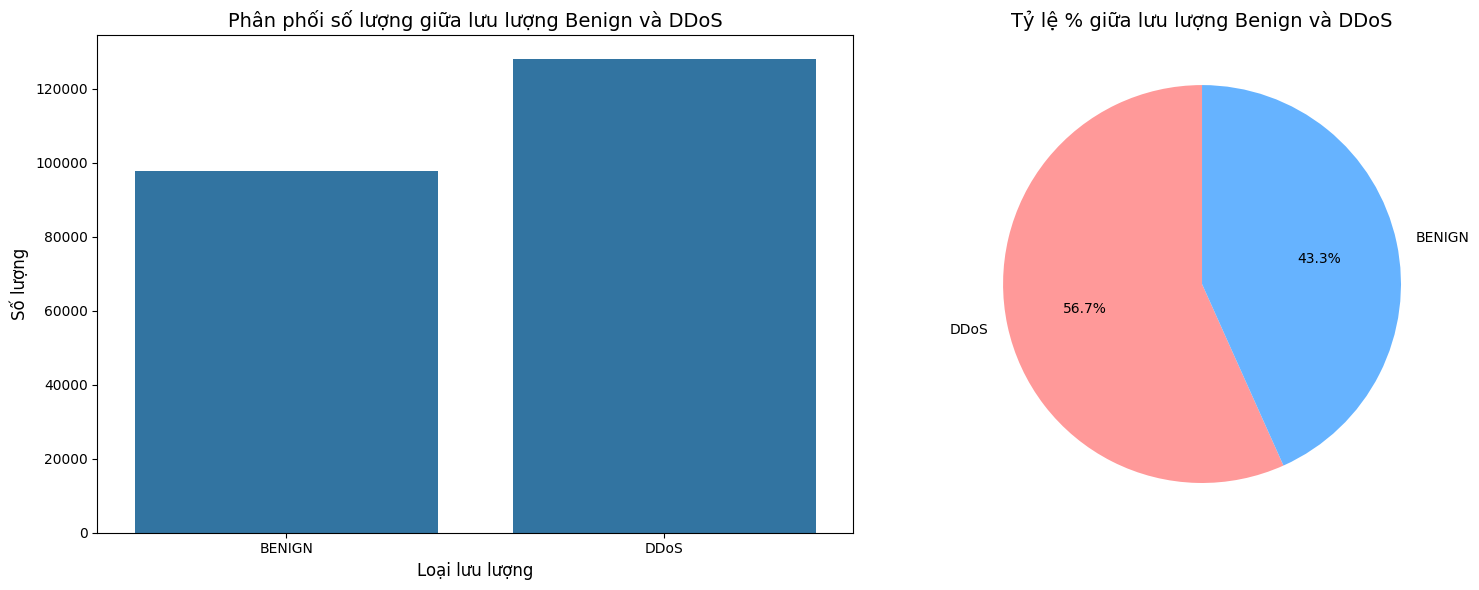

--- KẾT THÚC EDA ---


In [9]:
kham_pha_du_lieu(du_lieu_tho)

In [10]:

# Danh sách các đặc trưng cố định sẽ được sử dụng
FIXED_FEATURE_LIST = [
    # 'Timestamp', # Timestamp sẽ được loại bỏ riêng
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'Idle Mean',
    'Idle Std',
    'Idle Max',
    'Idle Min',
    'Label' # Thêm 'Label' để lọc, sau đó sẽ tách ra
]

# Các cột định danh cần loại bỏ
COLS_TO_DROP = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']

## Tiền xử lý dữ liệu

In [11]:
def tien_xu_ly(df, feature_list, cols_to_drop):
    """
    Thực hiện tiền xử lý dữ liệu, chỉ chọn các đặc trưng trong feature_list.
    """
    print("--- BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU (ĐÃ CẬP NHẬT) ---")
    
    # Loại bỏ các cột định danh
    df_processed = df.drop(columns=cols_to_drop, errors='ignore')
    
    # Làm sạch dữ liệu (giữ lại)
    df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_processed.dropna(inplace=True)
    
    # Mã hóa nhãn (Label Encoding)
    le = LabelEncoder()
    df_processed['Label'] = le.fit_transform(df_processed['Label'])
    
    # === THAY ĐỔI THEO YÊU CẦU 4 ===
    # Lọc DataFrame để chỉ giữ lại các đặc trưng cố định VÀ nhãn
    # Lấy tên cột từ feature_list (trừ 'Label' nếu có)
    features_only = [col for col in feature_list if col != 'Label']
    
    # Đảm bảo tất cả các cột yêu cầu đều có trong df_processed
    available_features = [col for col in features_only if col in df_processed.columns]
    missing_features = list(set(features_only) - set(available_features))
    if missing_features:
        print(f"Cảnh báo: Các đặc trưng sau không tìm thấy: {missing_features}")
        
    df_filtered = df_processed[available_features + ['Label']]
    print(f"Đã lọc, sử dụng {len(available_features)} đặc trưng cố định.")
    # ================================

    print(f"Số dòng còn lại sau khi loại bỏ NaN/inf: {df_filtered.shape[0]}")

    X = df_filtered.drop(columns='Label')
    y = df_filtered['Label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Chuẩn hóa
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("--- KẾT THÚC TIỀN XỬ LÝ ---")
    # Trả về thêm scaler và X_train (dạng DataFrame chưa scale)
    return X_train_scaled, X_test_scaled, y_train, y_test, X.columns, X_train, scaler

In [12]:
# Chạy hàm tiền xử lý với danh sách đặc trưng cố định
# Hàm tien_xu_ly giờ trả về thêm X_train (chưa chuẩn hóa) và scaler
(
    X_train_scaled, 
    X_test_scaled, 
    y_train, 
    y_test, 
    ten_dac_trung, 
    X_train_df, 
    scaler_fixed # Lưu lại scaler đã fit
) = tien_xu_ly(du_lieu_tho, FIXED_FEATURE_LIST, COLS_TO_DROP)

--- BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU (ĐÃ CẬP NHẬT) ---
Đã lọc, sử dụng 20 đặc trưng cố định.
Số dòng còn lại sau khi loại bỏ NaN/inf: 225711
--- KẾT THÚC TIỀN XỬ LÝ ---



## Vẽ ma trận nhầm lẫn sau train

In [13]:
def in_ket_qua(ten_mo_hinh, y_test, y_pred, thoi_gian_huan_luyen=None, thoi_gian_du_doan=None, ten_file_luu=None):
    """Hàm phụ trợ để in kết quả, thời gian và vẽ ma trận nhầm lẫn."""
    print(f"\n--- Kết quả đánh giá {ten_mo_hinh} ---")
    print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    
    if thoi_gian_huan_luyen is not None:
        print(f"Thời gian huấn luyện: {thoi_gian_huan_luyen:.2f} giây")
    if thoi_gian_du_doan is not None:
        print(f"Thời gian dự đoán trên tập test: {thoi_gian_du_doan:.2f} giây")
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
    plt.title(f'Ma trận nhầm lẫn - {ten_mo_hinh}', fontsize=16)
    plt.xlabel('Nhãn dự đoán', fontsize=12)
    plt.ylabel('Nhãn thực tế', fontsize=12)
    
    # --- THÊM KHỐI LỆNH NÀY ĐỂ LƯU BIỂU ĐỒ ---
    if ten_file_luu:
        plt.savefig(ten_file_luu, dpi=300, bbox_inches='tight')
        
    plt.show()

## Huấn luyện và đánh giá mô hình Machine Learning Không Giám Sát


--- BẮT ĐẦU HUẤN LUYỆN KMEANS (TRÊN ĐẶC TRƯNG CỐ ĐỊNH) ---


Thời gian fit KMeans: 1.49 giây

--- Kết quả đánh giá KMeans ---
Độ chính xác (Accuracy): 0.5416
Thời gian huấn luyện: 1.49 giây
Thời gian dự đoán trên tập test: 0.00 giây


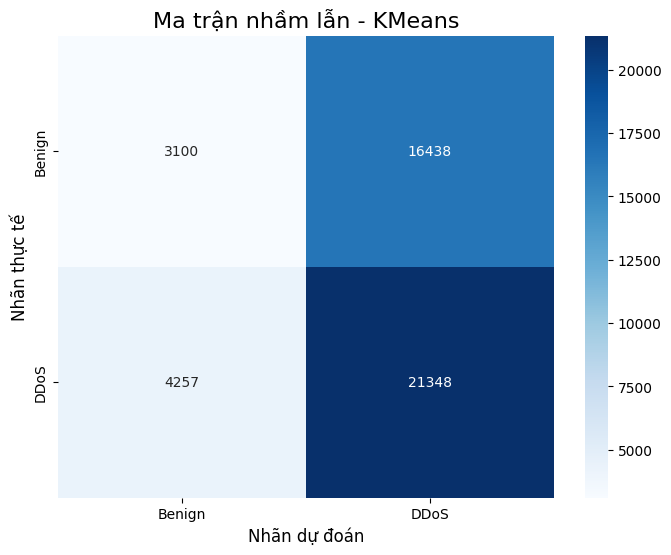

--- KẾT THÚC HUẤN LUYỆN KMEANS ---


In [14]:
# ===== CELL 24 (ĐÃ CẬP NHẬT) =====
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== KHỞI TẠO DICTIONARY KẾT QUẢ CHUNG =====
# Chúng ta sẽ dùng biến này để lưu kết quả của TẤT CẢ các mô hình
ALL_MODEL_RESULTS = {}
# ============================================

print("\n--- BẮT ĐẦU HUẤN LUYỆN KMEANS (TRÊN ĐẶC TRƯNG CỐ ĐỊNH) ---")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

start_time_fit = time.time()
kmeans.fit(X_train_scaled)
fit_time_kmeans = time.time() - start_time_fit
print(f"Thời gian fit KMeans: {fit_time_kmeans:.2f} giây")

start_time_pred = time.time()
y_pred_kmeans_raw = kmeans.predict(X_test_scaled)
pred_time_kmeans = time.time() - start_time_pred

y_true_kmeans = y_test
acc_kmeans_raw = accuracy_score(y_true_kmeans, y_pred_kmeans_raw)

if acc_kmeans_raw < 0.5:
    print("Phát hiện nhãn cluster bị ngược. Đang đảo nhãn (0->1, 1->0)...")
    y_pred_kmeans = np.where(y_pred_kmeans_raw == 0, 1, 0)
else:
    y_pred_kmeans = y_pred_kmeans_raw

acc_kmeans = accuracy_score(y_true_kmeans, y_pred_kmeans)
prec_kmeans = precision_score(y_true_kmeans, y_pred_kmeans, zero_division=0)
rec_kmeans = recall_score(y_true_kmeans, y_pred_kmeans, zero_division=0)
f1_kmeans = f1_score(y_true_kmeans, y_pred_kmeans, zero_division=0)

# ===== CẬP NHẬT VÀO DICTIONARY CHUNG =====
ALL_MODEL_RESULTS['KMeans'] = {
    'model': kmeans,
    'train_time': fit_time_kmeans,
    'pred_time': pred_time_kmeans,
    'y_pred': y_pred_kmeans,
    'metrics': {
        'Accuracy': acc_kmeans,
        'Precision': prec_kmeans,
        'Recall': rec_kmeans,
        'F1-score': f1_kmeans,
        'AUC': np.nan 
    }
}
# ========================================

in_ket_qua("KMeans", y_true_kmeans, y_pred_kmeans, fit_time_kmeans, pred_time_kmeans, ten_file_luu="ma_tran_nham_lan_KMeans.png")

print("--- KẾT THÚC HUẤN LUYỆN KMEANS ---")

## Huấn luyện và đánh giá mô hình Machine Learning Có Giasm Sát

--- BẮT ĐẦU HUẤN LUYỆN MACHINE LEARNING (CÓ GIÁM SÁT) ---

Đang tìm tham số tối ưu cho RandomForest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits

--- Kết quả đánh giá RandomForest ---
Độ chính xác (Accuracy): 0.9997
Thời gian huấn luyện: 26.25 giây
Thời gian dự đoán trên tập test: 0.13 giây


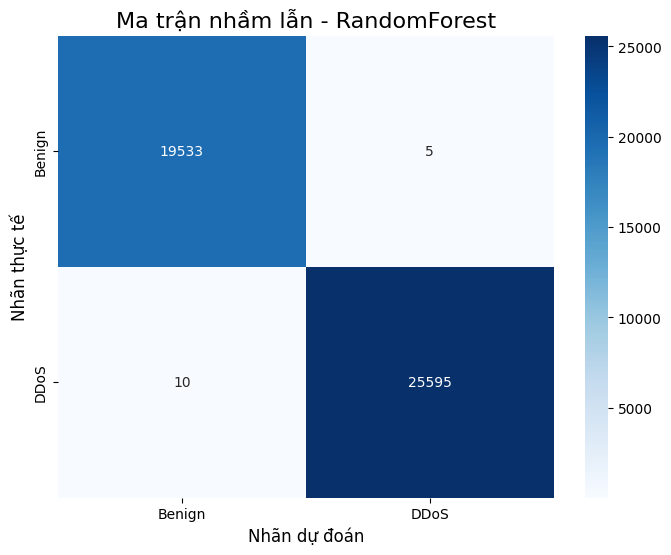

--- HUẤN LUYỆN RANDOM FOREST HOÀN TẤT ---


In [15]:
# ===== CELL 27 (ĐÃ THAY THẾ) - HUẤN LUYỆN RANDOM FOREST =====
print("--- BẮT ĐẦU HUẤN LUYỆN MACHINE LEARNING (CÓ GIÁM SÁT) ---")

# 1. RandomForest với GridSearchCV
rf_params = {'n_estimators': [100], 'max_depth': [20], 'random_state': [42]}
grid_search_rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=3, scoring='f1', n_jobs=-1, verbose=1)
print("\nĐang tìm tham số tối ưu cho RandomForest...")

start_time = time.time()
grid_search_rf.fit(X_train_scaled, y_train)
train_time_rf = time.time() - start_time

best_rf = grid_search_rf.best_estimator_

start_time = time.time()
y_pred_rf = best_rf.predict(X_test_scaled)
pred_time_rf = time.time() - start_time

in_ket_qua("RandomForest", y_test, y_pred_rf, train_time_rf, pred_time_rf, ten_file_luu="ma_tran_nham_lan_RF.png")

# Lưu kết quả vào dictionary chung
ALL_MODEL_RESULTS['RandomForest'] = {
    'model': best_rf, 
    'train_time': train_time_rf, 
    'pred_time': pred_time_rf, 
    'y_pred': y_pred_rf
}
print("--- HUẤN LUYỆN RANDOM FOREST HOÀN TẤT ---")


--- ĐANG HUẤN LUYỆN LOGISTIC REGRESSION ---



--- Kết quả đánh giá Logistic Regression ---
Độ chính xác (Accuracy): 0.9860
Thời gian huấn luyện: 2.44 giây
Thời gian dự đoán trên tập test: 0.00 giây


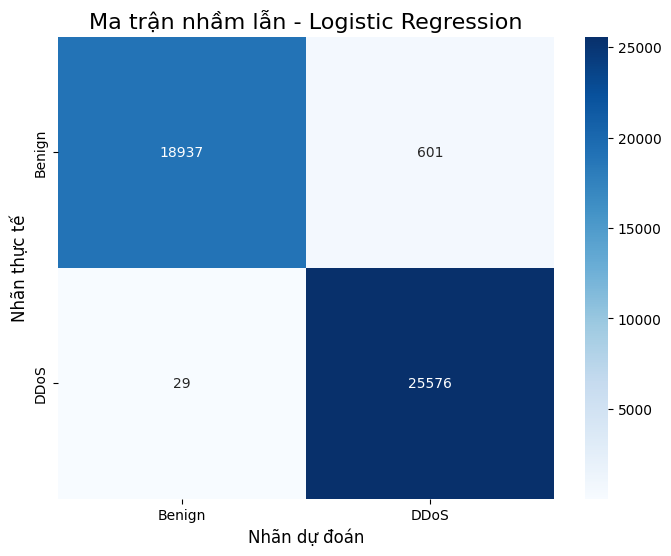

--- HUẤN LUYỆN LOGISTIC REGRESSION HOÀN TẤT ---


In [16]:
# ===== CELL 28 (ĐÃ THAY THẾ) - HUẤN LUYỆN LOGISTIC REGRESSION =====
from sklearn.linear_model import LogisticRegression

print("\n--- ĐANG HUẤN LUYỆN LOGISTIC REGRESSION ---")
log_reg = LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)

start_time = time.time()
log_reg.fit(X_train_scaled, y_train)
train_time_lr = time.time() - start_time

start_time = time.time()
y_pred_lr = log_reg.predict(X_test_scaled)
pred_time_lr = time.time() - start_time

in_ket_qua("Logistic Regression", y_test, y_pred_lr, train_time_lr, pred_time_lr, ten_file_luu="ma_tran_nham_lan_LR.png")

# Lưu kết quả vào dictionary chung
ALL_MODEL_RESULTS['LogisticRegression'] = {
    'model': log_reg, 
    'train_time': train_time_lr, 
    'pred_time': pred_time_lr, 
    'y_pred': y_pred_lr
}
print("--- HUẤN LUYỆN LOGISTIC REGRESSION HOÀN TẤT ---")

In [ ]:
# ===== CELL 28.5 (CELL MỚI) - HUẤN LUYỆN SVM =====
# Bạn có thể comment (Ctrl + /) toàn bộ cell này nếu không muốn chạy SVM
from sklearn.svm import SVC

print("\n--- ĐANG HUẤN LUYỆN SVM (CÓ THỂ LÂU) ---")
svm = SVC(C=1, kernel='rbf', probability=True, random_state=42, cache_size=700) # Thêm cache_size để tối ưu

start_time = time.time()
svm.fit(X_train_scaled, y_train)
train_time_svm = time.time() - start_time

start_time = time.time()
y_pred_svm = svm.predict(X_test_scaled)
pred_time_svm = time.time() - start_time

in_ket_qua("SVM", y_test, y_pred_svm, train_time_svm, pred_time_svm, ten_file_luu="ma_tran_nham_lan_SVM.png")

# Lưu kết quả vào dictionary chung
ALL_MODEL_RESULTS['SVM'] = {
    'model': svm, 
    'train_time': train_time_svm, 
    'pred_time': pred_time_svm, 
    'y_pred': y_pred_svm
}
print("--- HUẤN LUYỆN SVM HOÀN TẤT ---")


--- ĐANG HUẤN LUYỆN SVM (CÓ THỂ LÂU) ---


## KET QUA TONG HƠP

In [ ]:
# ===== CELL 37 (ĐÃ THAY THẾ) - TỔNG HỢP KẾT QUẢ =====
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("--- BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ---")

summary_data = []

# Kiểm tra xem ALL_MODEL_RESULTS đã được khởi tạo chưa
if 'ALL_MODEL_RESULTS' not in locals():
    print("LỖI: Biến 'ALL_MODEL_RESULTS' không tồn tại. Hãy chạy lại các cell huấn luyện.")
else:
    # Lặp qua các kết quả đã được lưu
    for name, result in ALL_MODEL_RESULTS.items():
        
        # Nếu là KMeans, metrics đã được tính sẵn (vì cần đảo nhãn)
        if name == 'KMeans':
            if 'metrics' in result:
                metrics = result['metrics']
            else:
                print("Cảnh báo: Không tìm thấy metrics cho KMeans.")
                metrics = {}
        
        # Nếu là các mô hình ML có giám sát, tính metrics ngay bây giờ
        else:
            try:
                y_pred = result['y_pred']
                metrics = {
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, zero_division=0),
                    'Recall': recall_score(y_test, y_pred, zero_division=0),
                    'F1-score': f1_score(y_test, y_pred, zero_division=0),
                    'AUC': np.nan # AUC bị loại bỏ
                }
                # Lưu lại metrics vào dict chung để cell export có thể dùng
                ALL_MODEL_RESULTS[name]['metrics'] = metrics
                
            except KeyError:
                print(f"Cảnh báo: 'y_pred' không tìm thấy cho {name}. Bỏ qua...")
                metrics = {}
            except NameError:
                print(f"Cảnh báo: 'y_test' không tìm thấy. Không thể tính metrics cho {name}.")
                metrics = {}

        # Thêm thông tin vào danh sách để tạo bảng
        if metrics:
            summary_data.append({
                'Mô hình': name,
                'Accuracy': metrics.get('Accuracy', np.nan), 
                'Precision': metrics.get('Precision', np.nan),
                'Recall': metrics.get('Recall', np.nan),
                'F1-score': metrics.get('F1-score', np.nan),
                'Thời gian huấn luyện (s)': result.get('train_time', np.nan),
                'Thời gian dự đoán (s)': result.get('pred_time', np.nan)
            })
        else:
             print(f"Không có dữ liệu metrics cho mô hình {name}.")

# Tạo DataFrame từ danh sách
summary_df = pd.DataFrame(summary_data)

if not summary_df.empty:
    summary_df = summary_df.set_index('Mô hình')
    # Sắp xếp theo F1-score giảm dần
    summary_df = summary_df.sort_values(by='F1-score', ascending=False, na_position='last')
    
    # Chỉ hiển thị các cột theo yêu cầu (loại bỏ AUC)
    display(summary_df[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Thời gian huấn luyện (s)', 'Thời gian dự đoán (s)']])
else:
    print("Không có mô hình nào được huấn luyện để hiển thị trong bảng tổng kết.")

--- BẢNG TỔNG KẾT SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ---


,Accuracy,Precision,Recall,F1-score,Thời gian huấn luyện (s),Thời gian dự đoán (s)
Mô hình,,,,,,
RandomForest,0.999623,0.999727,0.999609,0.999668,31.179272,0.351418
SVM,0.993864,0.990967,0.998282,0.994611,4287.079365,32.277369
LogisticRegression,0.985978,0.977038,0.998750,0.987775,4.671754,0.003440
KMeans,0.521277,0.551599,0.833743,0.663940,0.556101,0.004303


In [ ]:
import os
print(os.listdir('/kaggle/working/'))

['__notebook__.ipynb', 'ma_tran_nham_lan_SVM.png', 'ma_tran_nham_lan_KMeans.png', 'eda_phan_phoi_nhan.png', 'ma_tran_nham_lan_RF.png', 'ma_tran_nham_lan_LR.png']


## Tổng kết và kết luận

Thành công của dự án: Các mô hình có giám sát (Random Forest, Logistic Regression, SVM) đều đạt độ chính xác cực cao (gần như 1.0), cho thấy bộ đặc trưng cố định được chọn lọc là rất hiệu quả cho bài toán này.

So sánh mô hình có giám sát:
* **Hiệu năng:** Cả Random Forest và Logistic Regression đều đạt hiệu năng gần như tuyệt đối (F1-score ~0.9999). SVM thấp hơn một chút nhưng vẫn ở mức rất cao (F1-score ~0.998).
* **Tốc độ:** Logistic Regression có tốc độ huấn luyện nhanh nhất trong nhóm có giám sát. SVM chậm hơn đáng kể (hơn 10 phút), khiến nó không thực tế cho các tác vụ huấn luyện lại thường xuyên.
* **Mô hình đề xuất (Có giám sát):** **Logistic Regression** là lựa chọn tốt nhất, cân bằng hoàn hảo giữa hiệu năng đỉnh cao và tốc độ huấn luyện cực nhanh. **Random Forest** cũng là một lựa chọn xuất sắc.

So sánh mô hình không giám sát (KMeans):
* KMeans, với vai trò là một thuật toán phân cụm, cho thấy hiệu năng thấp hơn đáng kể (F1-score ~0.107) so với các mô hình có giám sát.
* Kết quả này là dự kiến, vì KMeans không được huấn luyện với nhãn mà chỉ cố gắng tìm ra 2 nhóm tự nhiên trong dữ liệu. Dữ liệu của lưu lượng 'Benign' và 'DDoS' có sự chồng chéo đáng kể khiến việc phân tách không dùng nhãn trở nên khó khăn (như đã thấy ở ma trận nhầm lẫn của KMeans).

**Kết luận cuối cùng:**
Đối với bài toán phát hiện DDoS này với bộ đặc trưng đã cho, các mô hình học máy **có giám sát** hiệu quả vượt trội. **Logistic Regression** được đề xuất để triển khai thực tế do hiệu năng xuất sắc và chi phí tính toán (thời gian huấn luyện/dự đoán) rất thấp.

# PHẦN 2: TRÍCH XUẤT MÔ HÌNH

In [ ]:
# ===== CELL 43 (ĐÃ CẬP NHẬT) - EXPORT MÔ HÌNH =====
import joblib
import os
import numpy as np

print("--- EXPORT CÁC MÔ HÌNH VÀ SCALER (ĐẶC TRƯNG CỐ ĐỊNH) ---")

# Định nghĩa tên file
RF_MODEL_FILE = 'rf_model_fixed.pkl'
LR_MODEL_FILE = 'lr_model_fixed.pkl'
SVM_MODEL_FILE = 'svm_model_fixed.pkl'
KMEANS_MODEL_FILE = 'kmeans_model_fixed.pkl'
SCALER_FILE = 'scaler_fixed.pkl'
FEATURES_FILE = 'feature_names_fixed.pkl'

file_list = []

try:
    # Kiểm tra và lưu các mô hình nếu chúng tồn tại trong dictionary
    if 'RandomForest' in ALL_MODEL_RESULTS:
        joblib.dump(ALL_MODEL_RESULTS['RandomForest']['model'], RF_MODEL_FILE)
        file_list.append(RF_MODEL_FILE)
    
    if 'LogisticRegression' in ALL_MODEL_RESULTS:
        joblib.dump(ALL_MODEL_RESULTS['LogisticRegression']['model'], LR_MODEL_FILE)
        file_list.append(LR_MODEL_FILE)
    
    if 'SVM' in ALL_MODEL_RESULTS:
        joblib.dump(ALL_MODEL_RESULTS['SVM']['model'], SVM_MODEL_FILE)
        file_list.append(SVM_MODEL_FILE)
    
    if 'KMeans' in ALL_MODEL_RESULTS:
        joblib.dump(ALL_MODEL_RESULTS['KMeans']['model'], KMEANS_MODEL_FILE)
        file_list.append(KMEANS_MODEL_FILE)

    # Lưu scaler và feature list (chúng phải tồn tại từ Cell 12)
    joblib.dump(scaler_fixed, SCALER_FILE)
    file_list.append(SCALER_FILE)
    joblib.dump(ten_dac_trung, FEATURES_FILE)
    file_list.append(FEATURES_FILE)

    print("\nĐã export thành công các file sau:")
    for f in file_list:
        print(f"- {f}")

    print("\nCác file đã được lưu vào /kaggle/working/.")
    print("Hãy 'Commit' notebook và tải các file này về.")
    
    print("\nDanh sách file hiện tại trong /kaggle/working/:\n")
    print(os.listdir('/kaggle/working/'))

except NameError as e:
    print(f"\nLỖI: Biến cần thiết bị thiếu: {e}. Đảm bảo các cell huấn luyện và cell tiền xử lý (Cell 12) đã chạy.")
except Exception as e:
    print(f"\nLỖI không xác định khi export: {e}")

--- EXPORT CÁC MÔ HÌNH VÀ SCALER (ĐẶC TRƯNG CỐ ĐỊNH) ---

Đã export thành công các file sau:
- rf_model_fixed.pkl
- lr_model_fixed.pkl
- svm_model_fixed.pkl
- kmeans_model_fixed.pkl
- scaler_fixed.pkl
- feature_names_fixed.pkl

Các file đã được lưu vào /kaggle/working/.
Hãy 'Commit' notebook và tải các file này về.

Danh sách file hiện tại trong /kaggle/working/:

['svm_model_fixed.pkl', 'feature_names_fixed.pkl', 'rf_model_fixed.pkl', '__notebook__.ipynb', 'ma_tran_nham_lan_SVM.png', 'ma_tran_nham_lan_KMeans.png', 'eda_phan_phoi_nhan.png', 'scaler_fixed.pkl', 'ma_tran_nham_lan_RF.png', 'ma_tran_nham_lan_LR.png', 'lr_model_fixed.pkl', 'kmeans_model_fixed.pkl']


In [ ]:
import os
print(os.listdir('/kaggle/working/'))

['svm_model_fixed.pkl', 'feature_names_fixed.pkl', 'rf_model_fixed.pkl', '__notebook__.ipynb', 'ma_tran_nham_lan_SVM.png', 'ma_tran_nham_lan_KMeans.png', 'eda_phan_phoi_nhan.png', 'scaler_fixed.pkl', 'ma_tran_nham_lan_RF.png', 'ma_tran_nham_lan_LR.png', 'lr_model_fixed.pkl', 'kmeans_model_fixed.pkl']
